# RQ19 — Cross-Password Generalisation

## Research question

> Can a True-Gate model generalise prospectively to a password that was not used during its development?

RQ18 established the controlled seven-password LOPO benchmark for the dissertation representation study. RQ19 addresses a different question: whether a model that had already been frozen could succeed on a genuinely unseen password. These two forms of evidence are kept separate.

RQ19 therefore distinguishes three levels of evidence.

### 1. Development-selected LOPO

The historical MAIN v8 development process recorded approximately:

- Top-1: **93.8%**
- Top-2: **99.0%**
- Top-3: **100%**

These values were produced while architecture, feature selection and other choices were being developed around Dataset v1. They are useful development estimates, but they are optimistic by construction and are not the final unbiased generalisation result.

### 2. Nested-LOPO sanity

A more conservative historical nested sanity check recorded approximately **85.2% Top-1**.

The exact original fold-level feature-selection/training record is not fully recovered, so this value is retained as an audit record rather than presented as a fresh exact replay.

### 3. Prospective frozen held-out password

This is the primary RQ19 experiment.

MAIN v7 was developed on **B01–B06 only** and frozen before B07 was evaluated.

Frozen source model:

`B01B02B03B04B05B06_MAIN_v7_FOCUS_PRE_B07.joblib`

The first B07 password challenge was **B07 = 9638**.

Only after this frozen evaluation was completed was B07 deliberately moved into development for MAIN v8. That chronology makes MAIN v7 → B07 the cleanest prospective cross-password test in the project.

The current operational model remains MAIN v8. RQ19 does not claim that the prospective B07 result is a clean unseen test of MAIN v8; it is prospective evidence for the immediately preceding frozen True-Gate model and therefore for the generalisation behaviour of the approach.

### Primary metrics

The experiment uses the 30 B07 fused profiles:

- W1: 10
- W2: 10
- W4: 10

Each profile fuses A/B by mean and CW/CCW 50:50 by physical digit, matching the archived prospective evaluation protocol.

Top-1, Top-2 and Top-3 are the primary metrics.

Macro/weighted F1 are reported only as supplementary metrics because B07 contains only three true positive digits across W1/W2/W4.


## 1. Locate the frozen project assets

In [1]:
from google.colab import drive
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount(
    "/content/drive"
)

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

PROJECT_ROOT = (
    MYDRIVE
    / "Padlock_Reproduction_v1"
)

results_candidates = [
    PROJECT_ROOT
    / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the active Padlock_Reproduction_v1/results."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_manifest.csv"
)

CACHE_PATH = (
    RESULTS_ROOT
    / "feature_cache"
    / "B07_9638_695d.npz"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "19_RQ19_Cross_Password_Generalisation"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RUNTIME_CANDIDATES = [
    RESULTS_ROOT.parent
    / "model_assets",
    PROJECT_ROOT
    / "model_assets",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "model_assets",
]

MODEL_ASSET_DIR = next(
    (
        p for p in RUNTIME_CANDIDATES
        if (
            p
            / "MAIN_v7_FOCUS_RUNTIME.json"
        ).exists()
    ),
    None,
)

if MODEL_ASSET_DIR is None:
    raise FileNotFoundError(
        "Could not locate MAIN_v7 runtime assets."
    )

RUNTIME_JSON = (
    MODEL_ASSET_DIR
    / "MAIN_v7_FOCUS_RUNTIME.json"
)

RUNTIME_NPZ = (
    MODEL_ASSET_DIR
    / "MAIN_v7_FOCUS_RUNTIME.npz"
)

ARCHIVE_DIR = (
    RESULTS_ROOT
    / "02_MAIN_v7_B07_heldout"
)

with open(
    RUNTIME_JSON,
    "r",
    encoding="utf-8",
) as f:
    meta = json.load(
        f
    )

actual_runtime_sha = hashlib.sha256(
    RUNTIME_NPZ.read_bytes()
).hexdigest()

expected_runtime_sha = meta[
    "runtime_npz_sha256"
]

if (
    actual_runtime_sha
    != expected_runtime_sha
):
    raise RuntimeError(
        "MAIN v7 runtime NPZ SHA-256 mismatch."
    )

if (
    meta[
        "training_scope"
    ]
    != "ONLY B01-B06"
):
    raise RuntimeError(
        "Prospective model is not the frozen B01-B06 model."
    )

print(
    "Results root:",
    RESULTS_ROOT,
)

print(
    "Model assets:",
    MODEL_ASSET_DIR,
)

print(
    "Frozen source model:",
    meta[
        "source_model"
    ],
)

print(
    "Training scope:",
    meta[
        "training_scope"
    ],
)

Mounted at /content/drive
Results root: /content/drive/MyDrive/Padlock_Reproduction_v1/results
Model assets: /content/drive/MyDrive/Padlock_Reproduction_v1/Padlock_Reproduction_v1/model_assets
Frozen source model: B01B02B03B04B05B06_MAIN_v7_FOCUS_PRE_B07.joblib
Training scope: ONLY B01-B06


## 2. Load B07 and reconstruct the frozen 695-D feature order

In [2]:
manifest = pd.read_csv(
    MANIFEST_PATH
)

b07 = (
    manifest[
        manifest[
            "batch"
        ]
        == "B07_9638"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

assert len(
    b07
) == 1200

assert b07[
    "profile_id"
].nunique() == 30

assert b07[
    "decision_uid"
].nunique() == 120


cache = np.load(
    CACHE_PATH,
    allow_pickle=False,
)

run_ids = cache[
    "run_ids"
].astype(
    str
)

features = cache[
    "features"
].astype(
    np.float64
)

run_index = {
    run_id: i
    for i, run_id
    in enumerate(
        run_ids
    )
}

X = np.vstack([
    features[
        run_index[
            run_id
        ]
    ]
    for run_id
    in b07[
        "run_id"
    ].astype(
        str
    )
])

assert X.shape == (
    1200,
    695,
)


feature_names = []

for channel in [
    1,
    2,
]:
    feature_names.extend(
        f"ch{channel}_fullmel_b{bin_index}_m{mel_index}"
        for bin_index in range(
            6
        )
        for mel_index in range(
            32
        )
    )

    feature_names.extend(
        f"ch{channel}_spec_{i}"
        for i in range(
            42
        )
    )

    feature_names.extend(
        f"ch{channel}_env_{i}"
        for i in range(
            16
        )
    )


feature_names.extend(
    f"ch1_minus_ch2_mel_{i}"
    for i in range(
        192
    )
)

feature_names.extend([
    "full_cross_corr",
    "full_log_rmsratio",
    "full_log_peakratio",
])

assert len(
    feature_names
) == 695

print(
    "B07 candidates:",
    len(
        b07
    ),
)

print(
    "B07 fused profiles:",
    b07[
        "profile_id"
    ].nunique(),
)

B07 candidates: 1200
B07 fused profiles: 30


## 3. Exact frozen MAIN v7 replay

In [3]:
from scipy.stats import rankdata

asset = np.load(
    RUNTIME_NPZ,
    allow_pickle=False,
)

selected_names = asset[
    "selected_feature_names"
].astype(
    str
)

name_to_index = {
    name: i
    for i, name
    in enumerate(
        feature_names
    )
}

selected_idx = np.array([
    name_to_index[
        name
    ]
    for name
    in selected_names
])

scaler_mean = asset[
    "scaler_mean"
].astype(
    np.float64
)

scaler_scale = asset[
    "scaler_scale"
].astype(
    np.float64
)

coef = asset[
    "coef"
].astype(
    np.float64
)

intercept = float(
    asset[
        "intercept"
    ][
        0
    ]
)

direction_alpha = float(
    asset[
        "direction_alpha"
    ][
        0
    ]
)

wheel_beta = float(
    asset[
        "wheel_beta"
    ][
        0
    ]
)

RANK_STD_10 = float(
    np.std(
        np.arange(
            1,
            11,
        ),
        ddof=0,
    )
)

score_parts = []

for (
    decision_uid,
    group,
) in b07.groupby(
    "decision_uid",
    sort=False,
):
    idx = group.index.to_numpy()

    x0 = X[
        idx
    ]

    median = np.median(
        x0,
        axis=0,
    )

    mad = np.median(
        np.abs(
            x0
            - median
        ),
        axis=0,
    )

    std = x0.std(
        axis=0
    )

    scale = np.where(
        1.4826
        * mad
        > 1e-6,
        1.4826
        * mad,
        np.where(
            std
            > 1e-6,
            std,
            1.0,
        ),
    )

    robust = np.clip(
        (
            x0
            - median
        )
        / scale,
        -12,
        12,
    )

    selected = robust[
        :,
        selected_idx,
    ]

    z = (
        selected
        - scaler_mean
    ) / scaler_scale

    wheel = int(
        group[
            "wheel"
        ].iloc[
            0
        ]
    )

    direction = str(
        group[
            "direction"
        ].iloc[
            0
        ]
    )

    direction_value = (
        1.0
        if direction
        == "CW"
        else -1.0
    )

    i2 = (
        1.0
        if wheel
        == 2
        else 0.0
    )

    i4 = (
        1.0
        if wheel
        == 4
        else 0.0
    )

    expanded = np.concatenate(
        [
            z,
            (
                direction_alpha
                * direction_value
                * z
            ),
            (
                wheel_beta
                * i2
                * z
            ),
            (
                wheel_beta
                * i4
                * z
            ),
            (
                direction_alpha
                * wheel_beta
                * direction_value
                * i2
                * z
            ),
            (
                direction_alpha
                * wheel_beta
                * direction_value
                * i4
                * z
            ),
        ],
        axis=1,
    )

    raw_score = (
        expanded
        @ coef
        + intercept
    )

    rank_score = (
        rankdata(
            raw_score
        )
        - 5.5
    ) / RANK_STD_10

    part = group.copy()

    part[
        "v7_rank_score"
    ] = rank_score

    score_parts.append(
        part
    )


candidate_scores = pd.concat(
    score_parts,
    ignore_index=True,
)

assert len(
    candidate_scores
) == 1200

## 4. Frozen A/B and CW/CCW fusion

In [4]:
direction_scores = (
    candidate_scores.groupby(
        [
            "profile_id",
            "wheel",
            "direction",
            "to_digit",
            "true_digit",
        ],
        as_index=False,
    )
    .agg(
        score=(
            "v7_rank_score",
            "mean",
        ),
        n_repeats=(
            "repeat_id",
            "nunique",
        ),
    )
)

assert direction_scores[
    "n_repeats"
].eq(
    2
).all()


profile_scores = (
    direction_scores.groupby(
        [
            "profile_id",
            "wheel",
            "to_digit",
            "true_digit",
        ],
        as_index=False,
    )
    .agg(
        score=(
            "score",
            "mean",
        ),
        n_directions=(
            "direction",
            "nunique",
        ),
    )
)

assert profile_scores[
    "n_directions"
].eq(
    2
).all()


prediction_rows = []

for (
    profile_id,
    wheel,
), group in profile_scores.groupby(
    [
        "profile_id",
        "wheel",
    ],
    sort=False,
):
    ranked = (
        group
        .sort_values(
            [
                "score",
                "to_digit",
            ],
            ascending=[
                False,
                True,
            ],
            kind="mergesort",
        )
        .reset_index(
            drop=True
        )
    )

    true_digit = int(
        ranked[
            "true_digit"
        ].iloc[
            0
        ]
    )

    digits = (
        ranked[
            "to_digit"
        ]
        .astype(
            int
        )
        .tolist()
    )

    prediction_rows.append({
        "profile_id": (
            profile_id
        ),
        "wheel": int(
            wheel
        ),
        "true_digit": (
            true_digit
        ),
        "pred_digit": int(
            digits[
                0
            ]
        ),
        "true_rank": int(
            digits.index(
                true_digit
            )
            + 1
        ),
        "top2": "|".join(
            map(
                str,
                digits[
                    :2
                ],
            )
        ),
        "top3": "|".join(
            map(
                str,
                digits[
                    :3
                ],
            )
        ),
    })


predictions = (
    pd.DataFrame(
        prediction_rows
    )
    .sort_values(
        "profile_id"
    )
    .reset_index(
        drop=True
    )
)

assert len(
    predictions
) == 30

display(
    predictions
)

,profile_id,wheel,true_digit,pred_digit,true_rank,top2,top3
0,B07_W1_P01,1,9,9,1,9|8,9|8|0
1,B07_W1_P02,1,9,7,3,7|8,7|8|9
2,B07_W1_P03,1,9,9,1,9|8,9|8|7
3,B07_W1_P04,1,9,9,1,9|7,9|7|4
4,B07_W1_P05,1,9,9,1,9|8,9|8|7
5,B07_W1_P06,1,9,9,1,9|8,9|8|6
6,B07_W1_P07,1,9,9,1,9|8,9|8|0
7,B07_W1_P08,1,9,9,1,9|8,9|8|7
8,B07_W1_P09,1,9,9,1,9|7,9|7|8
9,B07_W1_P10,1,9,9,1,9|7,9|7|8


## 5. Verify against the archived first B07 held-out result

In [5]:
if not (
    ARCHIVE_DIR
    / "predictions.csv"
).exists():
    raise FileNotFoundError(
        (
            "Archived prospective B07 predictions were not found at "
            f"{ARCHIVE_DIR}"
        )
    )

archived_predictions = (
    pd.read_csv(
        ARCHIVE_DIR
        / "predictions.csv"
    )
    .sort_values(
        "profile_id"
    )
    .reset_index(
        drop=True
    )
)

compare_cols = [
    "profile_id",
    "wheel",
    "true_digit",
    "pred_digit",
    "true_rank",
    "top2",
    "top3",
]

if not predictions[
    compare_cols
].equals(
    archived_predictions[
        compare_cols
    ]
):
    raise RuntimeError(
        "Fresh frozen-runtime replay does not match the archived first B07 score."
    )

print(
    "Exact archive match:",
    len(
        predictions
    ),
    "/",
    len(
        predictions
    ),
    "profiles",
)

Exact archive match: 30 / 30 profiles


## 6. Prospective B07 metrics

In [6]:
from sklearn.metrics import f1_score


def scope_metrics(
    frame,
    scope,
):
    y_true = frame[
        "true_digit"
    ]

    y_pred = frame[
        "pred_digit"
    ]

    return {
        "scope": scope,
        "n": len(
            frame
        ),
        "accuracy": float(
            np.mean(
                y_true
                == y_pred
            )
        ),
        "macro_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0,
            )
        ),
        "top1": float(
            np.mean(
                frame[
                    "true_rank"
                ]
                <= 1
            )
        ),
        "top2": float(
            np.mean(
                frame[
                    "true_rank"
                ]
                <= 2
            )
        ),
        "top3": float(
            np.mean(
                frame[
                    "true_rank"
                ]
                <= 3
            )
        ),
    }


summary_rows = [
    scope_metrics(
        predictions,
        "Overall",
    )
]

for wheel in [
    1,
    2,
    4,
]:
    summary_rows.append(
        scope_metrics(
            predictions[
                predictions[
                    "wheel"
                ]
                == wheel
            ],
            f"W{wheel}",
        )
    )


summary = pd.DataFrame(
    summary_rows
)

archived_summary = pd.read_csv(
    ARCHIVE_DIR
    / "summary_metrics.csv"
)

for column in [
    "n",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "top1",
    "top2",
    "top3",
]:
    if not np.allclose(
        summary[
            column
        ].to_numpy(
            dtype=float
        ),
        archived_summary[
            column
        ].to_numpy(
            dtype=float
        ),
        equal_nan=True,
    ):
        raise RuntimeError(
            (
                "Metric mismatch against archived prospective result: "
                f"{column}"
            )
        )


display(
    summary.round(
        4
    )
)

,scope,n,accuracy,macro_f1,weighted_f1,top1,top2,top3
0,Overall,30,0.8333,0.6327,0.8436,0.8333,0.9333,1.0
1,W1,10,0.9000,0.4737,0.9474,0.9000,0.9000,1.0
2,W2,10,0.6000,0.3750,0.7500,0.6000,0.9000,1.0
3,W4,10,1.0000,1.0000,1.0000,1.0000,1.0000,1.0


## 7. Generalisation evidence hierarchy

The following three Top-1 values should **not** be treated as a head-to-head model comparison. They represent different levels of evidential independence.

- Development-selected LOPO is useful for model development but optimistic.
- Nested-LOPO is a conservative internal sanity estimate.
- Frozen MAIN v7 → B07 is the prospective result because B07 had not been used when the model was frozen.

RQ18's 86.0% seven-password LOPO result is not inserted into this evidence hierarchy because it belongs to the controlled dissertation representation benchmark rather than the prospective operational-model chronology.

The 100% MAIN v8 replay on B01–B07 is deliberately excluded: MAIN v8 was fitted using B01–B07, so that result is only an in-sample runtime consistency check.


In [7]:
evidence = pd.DataFrame([
    {
        "evidence_level": (
            "Development-selected LOPO"
        ),
        "model": (
            "MAIN v8"
        ),
        "top1": 0.938,
        "top2": 0.990,
        "top3": 1.000,
        "status": (
            "Historical approximate development estimate"
        ),
    },
    {
        "evidence_level": (
            "Nested-LOPO sanity"
        ),
        "model": (
            "MAIN v8"
        ),
        "top1": 0.852,
        "top2": np.nan,
        "top3": np.nan,
        "status": (
            "Historical approximate sanity estimate"
        ),
    },
    {
        "evidence_level": (
            "Prospective frozen B07"
        ),
        "model": (
            "MAIN v7"
        ),
        "top1": float(
            summary.loc[
                summary[
                    "scope"
                ]
                == "Overall",
                "top1",
            ].iloc[
                0
            ]
        ),
        "top2": float(
            summary.loc[
                summary[
                    "scope"
                ]
                == "Overall",
                "top2",
            ].iloc[
                0
            ]
        ),
        "top3": float(
            summary.loc[
                summary[
                    "scope"
                ]
                == "Overall",
                "top3",
            ].iloc[
                0
            ]
        ),
        "status": (
            "Exact frozen prospective held-out replay"
        ),
    },
])

display(
    evidence
)

,evidence_level,model,top1,top2,top3,status
0,Development-selected LOPO,MAIN v8,0.938000,0.990000,1.0,Historical approximate development estimate
1,Nested-LOPO sanity,MAIN v8,0.852000,NaN,NaN,Historical approximate sanity estimate
2,Prospective frozen B07,MAIN v7,0.833333,0.933333,1.0,Exact frozen prospective held-out replay


## 8. Main figures

In [8]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
PALE_BLUE = "#DCE8F0"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

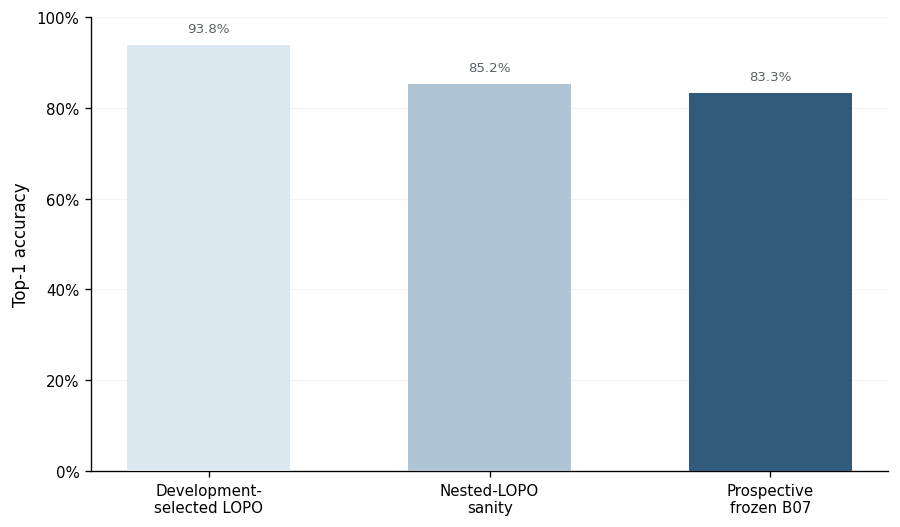

In [9]:
# Figure 1 — evidence hierarchy, not a head-to-head model comparison.

fig, ax = plt.subplots(
    figsize=(
        7.6,
        4.5,
    )
)

x = np.arange(
    3
)

values = (
    100
    * evidence[
        "top1"
    ].to_numpy()
)

bars = ax.bar(
    x,
    values,
    width=0.58,
    color=[
        PALE_BLUE,
        LIGHT_BLUE,
        DARK_BLUE,
    ],
    edgecolor="none",
    zorder=3,
)

for (
    bar,
    value,
) in zip(
    bars,
    values,
):
    ax.annotate(
        f"{value:.1f}%",
        xy=(
            bar.get_x()
            + bar.get_width()
            / 2,
            value,
        ),
        xytext=(
            0,
            6,
        ),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color=DARK_GREY,
    )


ax.set_xticks(
    x
)

ax.set_xticklabels([
    "Development-\nselected LOPO",
    "Nested-LOPO\nsanity",
    "Prospective\nfrozen B07",
])

ax.set_ylabel(
    "Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ19_Fig1_generalisation_evidence",
)

plt.show()

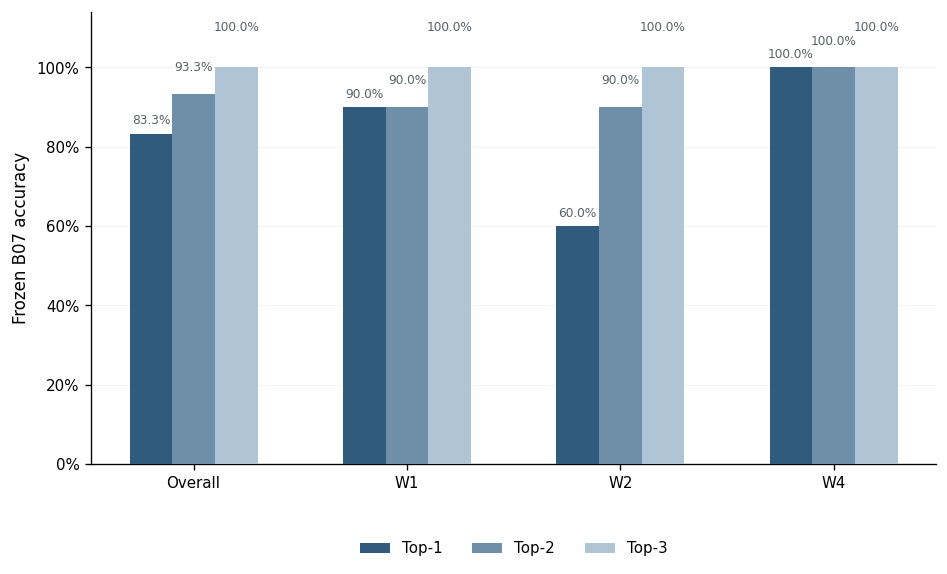

In [10]:
# Figure 2 — exact frozen B07 Top-k by wheel.

scope_order = [
    "Overall",
    "W1",
    "W2",
    "W4",
]

plot = (
    summary
    .set_index(
        "scope"
    )
    .reindex(
        scope_order
    )
)

fig, ax = plt.subplots(
    figsize=(
        8.0,
        4.8,
    )
)

x = np.arange(
    4
)

width = 0.20

series = [
    (
        -width,
        "top1",
        DARK_BLUE,
        "Top-1",
        4,
    ),
    (
        0.0,
        "top2",
        MID_BLUE,
        "Top-2",
        12,
    ),
    (
        width,
        "top3",
        LIGHT_BLUE,
        "Top-3",
        20,
    ),
]

for (
    offset,
    metric,
    color,
    label,
    text_offset,
) in series:
    values = (
        100
        * plot[
            metric
        ].to_numpy()
    )

    bars = ax.bar(
        x
        + offset,
        values,
        width=width,
        color=color,
        edgecolor="none",
        label=label,
        zorder=3,
    )

    for (
        bar,
        value,
    ) in zip(
        bars,
        values,
    ):
        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                value,
            ),
            xytext=(
                0,
                text_offset,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.3,
            color=DARK_GREY,
        )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    scope_order
)

ax.set_ylabel(
    "Frozen B07 accuracy"
)

ax.set_ylim(
    0,
    114,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.14,
    ),
)

fig.subplots_adjust(
    bottom=0.22
)

fig.tight_layout()

save_figure(
    fig,
    "RQ19_Fig2_B07_topk_by_wheel",
)

plt.show()

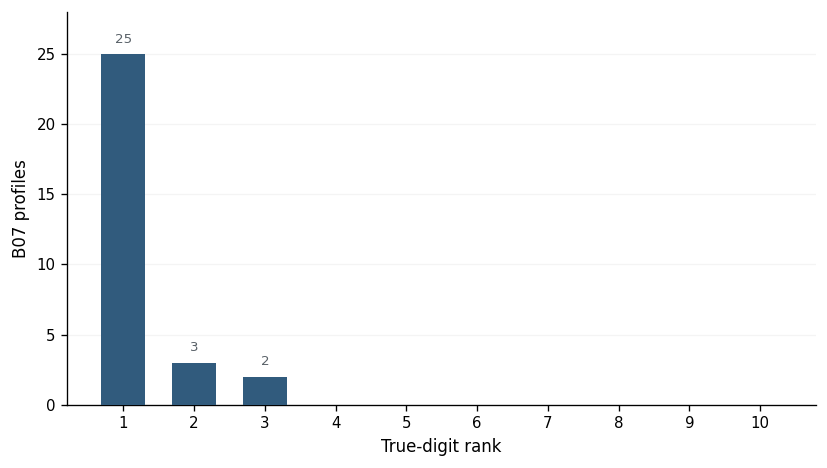

In [11]:
# Figure 3 — exact true-rank distribution on the prospective password.

rank_table = (
    predictions[
        "true_rank"
    ]
    .value_counts()
    .sort_index()
    .reindex(
        range(
            1,
            11,
        ),
        fill_value=0,
    )
    .rename(
        "n_profiles"
    )
    .rename_axis(
        "true_rank"
    )
    .reset_index()
)

fig, ax = plt.subplots(
    figsize=(
        7.0,
        4.0,
    )
)

bars = ax.bar(
    rank_table[
        "true_rank"
    ],
    rank_table[
        "n_profiles"
    ],
    width=0.62,
    color=DARK_BLUE,
    edgecolor="none",
    zorder=3,
)

for (
    bar,
    value,
) in zip(
    bars,
    rank_table[
        "n_profiles"
    ],
):
    if value > 0:
        ax.annotate(
            str(
                int(
                    value
                )
            ),
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                value,
            ),
            xytext=(
                0,
                5,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=DARK_GREY,
        )


ax.set_xticks(
    np.arange(
        1,
        11,
    )
)

ax.set_xlabel(
    "True-digit rank"
)

ax.set_ylabel(
    "B07 profiles"
)

ax.set_ylim(
    0,
    28,
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ19_Fig3_B07_rank_distribution",
)

plt.show()

## 9. Tables and result record

In [12]:
predictions.to_csv(
    RESULT_DIR
    / "RQ19_B07_predictions.csv",
    index=False,
)

candidate_scores.to_csv(
    RESULT_DIR
    / "RQ19_B07_candidate_scores.csv",
    index=False,
)

summary.to_csv(
    RESULT_DIR
    / "RQ19_B07_summary_metrics.csv",
    index=False,
)

evidence.to_csv(
    RESULT_DIR
    / "RQ19_generalisation_evidence.csv",
    index=False,
)

rank_table.to_csv(
    RESULT_DIR
    / "RQ19_B07_rank_distribution.csv",
    index=False,
)


excluded_check = pd.DataFrame([
    {
        "result": (
            "MAIN v8 runtime replay on B01-B07"
        ),
        "top1": 1.0,
        "status": (
            "In-sample runtime consistency only"
        ),
        "reason_excluded": (
            "MAIN v8 was fitted using B01-B07; "
            "100% replay is not unseen evaluation."
        ),
    }
])

excluded_check.to_csv(
    RESULT_DIR
    / "RQ19_excluded_in_sample_check.csv",
    index=False,
)


table1 = evidence.copy()

for (
    col,
    label,
) in [
    (
        "top1",
        "Top-1",
    ),
    (
        "top2",
        "Top-2",
    ),
    (
        "top3",
        "Top-3",
    ),
]:
    table1[
        label
    ] = table1[
        col
    ].map(
        lambda x: (
            "—"
            if pd.isna(
                x
            )
            else f"{100 * x:.1f}%"
        )
    )


table1 = table1[
    [
        "evidence_level",
        "model",
        "Top-1",
        "Top-2",
        "Top-3",
        "status",
    ]
].rename(
    columns={
        "evidence_level": (
            "Evidence level"
        ),
        "model": "Model",
        "status": "Status",
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ19_Table1_generalisation_evidence.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ19_Table1_generalisation_evidence.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = summary.copy()

for (
    col,
    label,
) in [
    (
        "accuracy",
        "Accuracy",
    ),
    (
        "top1",
        "Top-1",
    ),
    (
        "top2",
        "Top-2",
    ),
    (
        "top3",
        "Top-3",
    ),
]:
    table2[
        label
    ] = (
        100
        * table2[
            col
        ]
    ).map(
        lambda x: f"{x:.1f}%"
    )


table2[
    "Macro F1"
] = table2[
    "macro_f1"
].map(
    lambda x: f"{x:.3f}"
)

table2[
    "Weighted F1"
] = table2[
    "weighted_f1"
].map(
    lambda x: f"{x:.3f}"
)

table2 = table2[
    [
        "scope",
        "n",
        "Accuracy",
        "Top-1",
        "Top-2",
        "Top-3",
        "Macro F1",
        "Weighted F1",
    ]
].rename(
    columns={
        "scope": "Scope",
        "n": "N profiles",
    }
)

table2.to_csv(
    RESULT_DIR
    / "RQ19_Table2_B07_summary.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ19_Table2_B07_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    table2
)

,Evidence level,Model,Top-1,Top-2,Top-3,Status
0,Development-selected LOPO,MAIN v8,93.8%,99.0%,100.0%,Historical approximate development estimate
1,Nested-LOPO sanity,MAIN v8,85.2%,—,—,Historical approximate sanity estimate
2,Prospective frozen B07,MAIN v7,83.3%,93.3%,100.0%,Exact frozen prospective held-out replay


,Scope,N profiles,Accuracy,Top-1,Top-2,Top-3,Macro F1,Weighted F1
0,Overall,30,83.3%,83.3%,93.3%,100.0%,0.633,0.844
1,W1,10,90.0%,90.0%,90.0%,100.0%,0.474,0.947
2,W2,10,60.0%,60.0%,90.0%,100.0%,0.375,0.750
3,W4,10,100.0%,100.0%,100.0%,100.0%,1.000,1.000


In [13]:
overall_row = summary[
    summary[
        "scope"
    ]
    == "Overall"
].iloc[
    0
]

conclusion = {
    "research_question": (
        "Can a frozen True-Gate model generalise prospectively to a password "
        "that was not used during its development?"
    ),
    "prospective_model": (
        meta[
            "source_model"
        ]
    ),
    "training_scope": (
        meta[
            "training_scope"
        ]
    ),
    "heldout_password": (
        "B07_9638"
    ),
    "prospective_B07": {
        "top1": float(
            overall_row[
                "top1"
            ]
        ),
        "top2": float(
            overall_row[
                "top2"
            ]
        ),
        "top3": float(
            overall_row[
                "top3"
            ]
        ),
        "macro_f1": float(
            overall_row[
                "macro_f1"
            ]
        ),
        "weighted_f1": float(
            overall_row[
                "weighted_f1"
            ]
        ),
    },
    "development_reference": {
        "MAIN_v8_development_selected_LOPO_top1_approx": (
            0.938
        ),
        "MAIN_v8_nested_LOPO_sanity_top1_approx": (
            0.852
        ),
        "status": (
            "Historical audit values, not fresh exact fold replays."
        ),
        "RQ18_controlled_695D_LogReg_LOPO_top1": 0.8595238095238096,
        "RQ18_status": (
            "Separate controlled dissertation benchmark; not prospective MAIN v8 evidence."
        ),
    },
    "replay_validation": (
        "Fresh runtime reconstruction reproduces every archived B07 "
        "profile prediction, true rank, Top-2 and Top-3 list exactly."
    ),
    "chronology": (
        "MAIN v7 was developed on B01-B06 and frozen before B07 was "
        "first scored. B07 entered development only after this evaluation."
    ),
    "interpretation": (
        "The prospective B07 result is the strongest unbiased cross-password "
        "evidence in the project. Top-1 is 83.3%, Top-2 93.3%, and Top-3 "
        "100%. W1 reaches 90% Top-1, W2 60%, and W4 100%. The lower frozen "
        "prospective result relative to the approximately 93.8% development-selected "
        "LOPO estimate demonstrates why the development estimate should not be "
        "presented as final generalisation accuracy."
    ),
    "limitations": (
        "Only one password was kept clean for prospective evaluation. The 30 "
        "profiles measure within-password robustness but do not estimate "
        "password-to-password uncertainty. Historical development-selected and "
        "nested-LOPO figures remain approximate because the original fold-level "
        "feature-selection procedure is not fully recoverable."
    ),
    "decision": (
        "Use MAIN v7 -> B07 83.3% Top-1 as the primary prospective "
        "cross-password generalisation result. Report MAIN v8 development-selected "
        "LOPO separately and explicitly as optimistic. Do not use the 100% "
        "MAIN v8 B01-B07 runtime replay as unseen evidence."
    ),
    "next_step": (
        "RQ20 tests whether downstream-wheel acoustics depend on the correctness "
        "of the already selected upstream prefix."
    ),
}


with open(
    RESULT_DIR
    / "RQ19_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "19_RQ19_Cross_Password_Generalisation.ipynb"
    ),
    "source_model": (
        meta[
            "source_model"
        ]
    ),
    "source_model_sha256": (
        meta[
            "source_model_sha256"
        ]
    ),
    "training_scope": (
        meta[
            "training_scope"
        ]
    ),
    "heldout_batch": (
        "B07_9638"
    ),
    "runtime_archive_match": True,
    "primary_metric": (
        "Prospective frozen B07 Top-1"
    ),
}


with open(
    RESULT_DIR
    / "RQ19_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ19_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Can a frozen True-Gate model generalise prospectively to a password that was not used during its development?",
  "prospective_model": "B01B02B03B04B05B06_MAIN_v7_FOCUS_PRE_B07.joblib",
  "training_scope": "ONLY B01-B06",
  "heldout_password": "B07_9638",
  "prospective_B07": {
    "top1": 0.8333333333333334,
    "top2": 0.9333333333333333,
    "top3": 1.0,
    "macro_f1": 0.6326754385964912,
    "weighted_f1": 0.8435672514619884
  },
  "development_reference": {
    "MAIN_v8_development_selected_LOPO_top1_approx": 0.938,
    "MAIN_v8_nested_LOPO_sanity_top1_approx": 0.852,
    "status": "Historical audit values, not fresh exact fold replays.",
    "RQ18_controlled_695D_LogReg_LOPO_top1": 0.8595238095238096,
    "RQ18_status": "Separate controlled dissertation benchmark; not prospective MAIN v8 evidence."
  },
  "replay_validation": "Fresh runtime reconstruction reproduces every archived B07 profile prediction, true rank, Top-2 and Top-3 list exactly.",
  "chr